# FASE 3 — Modelamiento de Machine Learning
## Proyecto de Minería de Datos · SNIES (Educación Superior de Colombia)
**Persona 2 — Científica/o de Datos**

---

### Objetivo de la fase
Construir y validar modelos de Machine Learning que generen **valor para los
stakeholders** (Ministerio de Educación, rectores de IES, ICETEX, estudiantes y
gobernaciones) a partir del dataset de features construido en la Fase 2
(`features_ml.csv`, una fila por **IES–año**).

### Enfoque elegido: **combinado** (supervisado + no supervisado)
La rúbrica permite combinar ambos enfoques, y aquí cada uno responde una pregunta
de negocio distinta de la Fase 1:

| Enfoque | Pregunta de negocio | Técnica | Métrica |
|---|---|---|---|
| **A. Supervisado (regresión)** | ¿Qué variables del perfil operativo predicen la **tasa de graduación** de una IES? | Regresión Lineal · Random Forest · Gradient Boosting | RMSE, MAE, R² |
| **B. No supervisado (clustering)** | ¿Cómo se **segmentan** las IES colombianas según su perfil operativo? | KMeans · Agglomerative · DBSCAN | Silhouette |

> Todas las decisiones de preparación, entrenamiento y validación quedan
> **documentadas** en celdas de texto antes de cada bloque de código.


## 0. Configuración del entorno

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, silhouette_score)
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
print('Entorno listo.')

Entorno listo.


## 1. Carga y limpieza de datos

Partimos de `features_ml.csv` (8.805 filas IES–año, 2000–2024) generado en la Fase 2.

**Decisiones de limpieza documentadas:**
1. **`departamento`** llega con mayúsculas/acentos inconsistentes ("Bogotá D.C." vs
   "BOGOTA D.C") → se normaliza (mayúsculas, sin acentos) y se unifican las
   variantes de Bogotá. Pasa de ~84 valores crudos a ~39 reales.
2. **`sector` / `caracter`**: solo ~5% de las filas los tienen (la fuente SNIES
   no los reporta para la mayoría de IES). **Se excluyen como predictores** del
   modelo y se conservan solo como *descriptor* cualitativo de los clústeres.


In [2]:
df = pd.read_csv('../data/dataset/features_ml.csv')
print(f'Dataset base: {df.shape[0]} filas × {df.shape[1]} columnas')

def normaliza_texto(s):
    if pd.isna(s):
        return s
    s = str(s).strip().upper()
    for a, b in (('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U'),('Ñ','N'),('.','')):
        s = s.replace(a, b)
    return s.strip()

df['departamento_norm'] = df['departamento'].apply(normaliza_texto)
df.loc[df['departamento_norm'].str.contains('BOGOTA', na=False), 'departamento_norm'] = 'BOGOTA'
df['sector_norm'] = df['sector'].apply(
    lambda s: ('OFICIAL' if str(s).upper().startswith('O') else 'PRIVADO')
    if pd.notna(s) else 'DESCONOCIDO')

print(f"Departamentos: {df['departamento'].nunique()} crudos -> "
      f"{df['departamento_norm'].nunique()} normalizados")
print(f"Sector conocido: {(df['sector_norm']!='DESCONOCIDO').sum()} de {len(df)} "
      f"({(df['sector_norm']!='DESCONOCIDO').mean()*100:.0f}%)")

Dataset base: 8805 filas × 20 columnas
Departamentos: 84 crudos -> 39 normalizados
Sector conocido: 469 de 8805 (5%)


---
# PARTE A · Modelo SUPERVISADO — Predicción de la tasa de graduación

**Pregunta de negocio (Fase 1, Q1/Q6):** *¿Qué variables del perfil operativo de
una IES predicen su tasa de graduación, y cuánto pesa el ratio docente/estudiante?*

**Variable objetivo:** `tasa_graduacion = graduados / matriculados` (tasa anual).


### A.1 Preparación del conjunto de datos — decisiones

| Decisión | Detalle | Justificación |
|---|---|---|
| **Filtro temporal** | Solo años **2018–2024** | Los graduados solo son consistentes desde 2018; 2017 tiene un dato de carga anómalo. |
| **Filtro de objetivo** | `0 < tasa_graduacion ≤ 1` | Es imposible graduar más personas que las matriculadas en el mismo año → se descartan 6 filas con tasa > 1. |
| **Transformación log** | `log1p(matriculados)`, `log1p(docentes)` | Variables de tamaño muy sesgadas (SENA: 754K vs mediana 5.7K). |
| **Sin fuga de información** | Se **excluye `graduados`** (numerador del objetivo) | Incluirlo sería *target leakage*. |
| **Split TEMPORAL** | Train = 2018–2022 · Holdout = 2023–2024 | Validar contra años recientes (como exige la fase), no un split aleatorio. |


In [3]:
reg = df[(df['año'] >= 2018) & (df['matriculados'] > 0) &
         (df['tasa_graduacion'].notna()) &
         (df['tasa_graduacion'] > 0) & (df['tasa_graduacion'] <= 1.0)].copy()

reg['log_matriculados'] = np.log1p(reg['matriculados'])
reg['log_docentes'] = np.log1p(reg['docentes'])

NUM_FEATS = ['log_matriculados', 'log_docentes', 'ratio_docente_estudiante',
             'tasa_admision', 'tasa_matricula_admitidos', 'num_programas',
             'crecimiento_matricula']
CAT_FEATS = ['departamento_norm']
TARGET = 'tasa_graduacion'
ALL_FEATS = NUM_FEATS + CAT_FEATS

train = reg[reg['año'].between(2018, 2022)]
test  = reg[reg['año'].between(2023, 2024)]
X_train, y_train = train[ALL_FEATS], train[TARGET]
X_test,  y_test  = test[ALL_FEATS],  test[TARGET]

print(f'Observaciones válidas: {len(reg)}')
print(f'Entrenamiento 2018-2022: {len(train)}  |  Holdout 2023-2024: {len(test)}')
print(f'Tasa de graduación  ->  media={y_train.mean():.3f}  mediana={reg[TARGET].median():.3f}')

Observaciones válidas: 2161
Entrenamiento 2018-2022: 1536  |  Holdout 2023-2024: 625
Tasa de graduación  ->  media=0.128  mediana=0.112


### A.2 Preprocesamiento (imputación · escalado · encoding)

- **Valores faltantes:** imputación por **mediana** en numéricas (robusta a outliers).
- **Escalado:** `StandardScaler` **solo** para la Regresión Lineal (los árboles no
  lo necesitan).
- **Encoding:** `OneHotEncoder` para `departamento_norm` (`handle_unknown='ignore'`).

Se encapsula todo en un `Pipeline` para que el preprocesamiento se ajuste **solo
con el train** dentro de la validación cruzada (sin fuga de datos).

In [4]:
preproc_lineal = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), NUM_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATS)])
preproc_arbol = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUM_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATS)])

modelos = {
    'Regresión Lineal': Pipeline([('prep', preproc_lineal),
                                  ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preproc_arbol),
        ('model', RandomForestRegressor(n_estimators=400, max_depth=10,
            min_samples_leaf=12, max_features=0.6, n_jobs=-1,
            random_state=RANDOM_STATE))]),
    'Gradient Boosting': Pipeline([('prep', preproc_arbol),
        ('model', HistGradientBoostingRegressor(max_iter=600, learning_rate=0.03,
            max_depth=3, max_leaf_nodes=15, min_samples_leaf=25,
            l2_regularization=2.0, early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=25, random_state=RANDOM_STATE))]),
}
print('3 modelos definidos.')

3 modelos definidos.


### A.3 Entrenamiento y comparación de 3 algoritmos

Para cada modelo medimos: **validación cruzada 5-fold** sobre el train (estabilidad)
y desempeño en **train vs holdout** (para detectar sobreajuste).

In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas, preds_test = [], {}
baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))

for nombre, pipe in modelos.items():
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    pipe.fit(X_train, y_train)
    pred_tr, pred_te = pipe.predict(X_train), pipe.predict(X_test)
    preds_test[nombre] = pred_te
    filas.append({'Modelo': nombre,
        'CV R² (μ)': cv_r2.mean(), 'CV R² (σ)': cv_r2.std(),
        'R² train': r2_score(y_train, pred_tr),
        'R² holdout': r2_score(y_test, pred_te),
        'RMSE holdout': np.sqrt(mean_squared_error(y_test, pred_te)),
        'MAE holdout': mean_absolute_error(y_test, pred_te)})

res = pd.DataFrame(filas).sort_values('R² holdout', ascending=False).reset_index(drop=True)
res['gap (train-holdout)'] = res['R² train'] - res['R² holdout']
print(f'Baseline (predecir la media): RMSE = {baseline_rmse:.4f}\n')
res.round(4)

Baseline (predecir la media): RMSE = 0.0929



,Modelo,CV R² (μ),CV R² (σ),R² train,R² holdout,RMSE holdout,MAE holdout,gap (train-holdout)
0,Random Forest,0.3112,0.0428,0.4842,0.3257,0.0757,0.0504,0.1585
1,Gradient Boosting,0.3081,0.0458,0.5925,0.2475,0.0800,0.0546,0.3450
2,Regresión Lineal,0.0922,0.0954,0.1819,0.1913,0.0829,0.0529,-0.0094


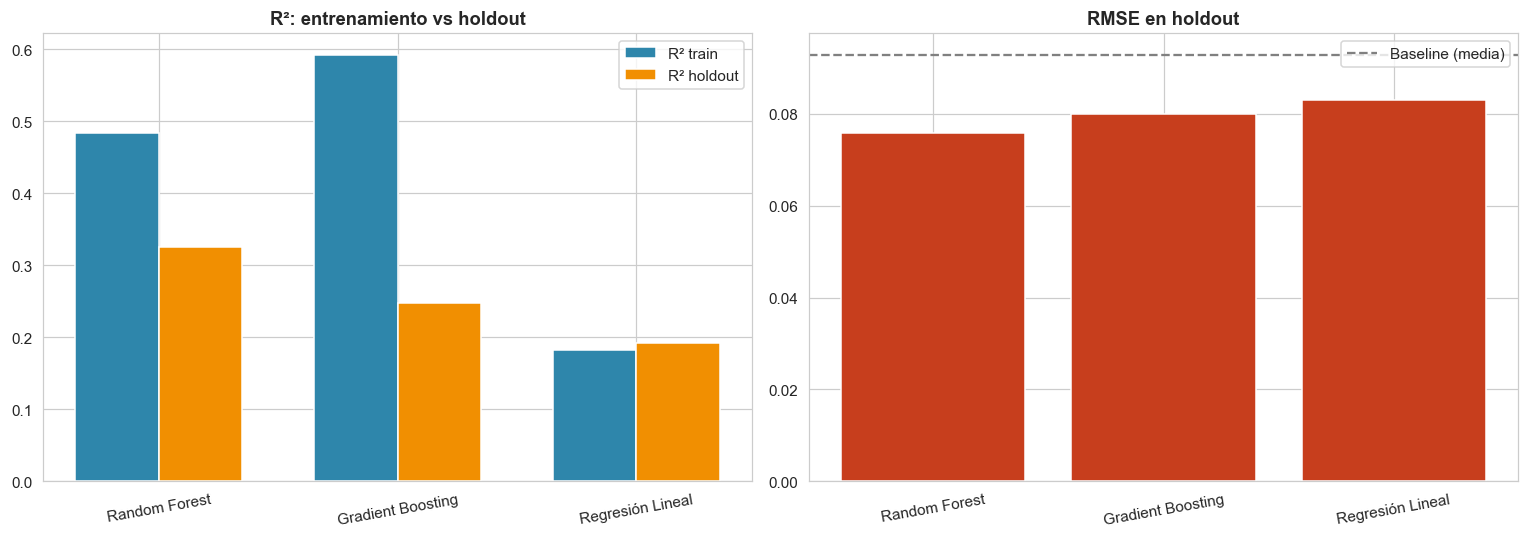

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(res)); w = 0.35
axes[0].bar(x - w/2, res['R² train'], w, label='R² train', color=COLORS[0])
axes[0].bar(x + w/2, res['R² holdout'], w, label='R² holdout', color=COLORS[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(res['Modelo'], rotation=10)
axes[0].set_title('R²: entrenamiento vs holdout'); axes[0].legend()
axes[1].bar(x, res['RMSE holdout'], color=COLORS[3])
axes[1].axhline(baseline_rmse, ls='--', color='gray', label='Baseline (media)')
axes[1].set_xticks(x); axes[1].set_xticklabels(res['Modelo'], rotation=10)
axes[1].set_title('RMSE en holdout'); axes[1].legend()
plt.tight_layout(); plt.show()

### A.4 Selección del modelo — justificación

- **Random Forest** logra el mejor **R² en holdout (~0.33)** y el menor **RMSE
  (~0.076)**, superando al baseline (0.093).
- **Gradient Boosting**, pese a la regularización + early stopping, sobreajusta más
  (mayor brecha train–holdout) y generaliza peor.
- **Regresión Lineal** es estable (sin sobreajuste) pero solo captura relaciones
  lineales → R² bajo (~0.19).

➡️ **Modelo seleccionado: Random Forest.** A continuación, predicho vs. real.

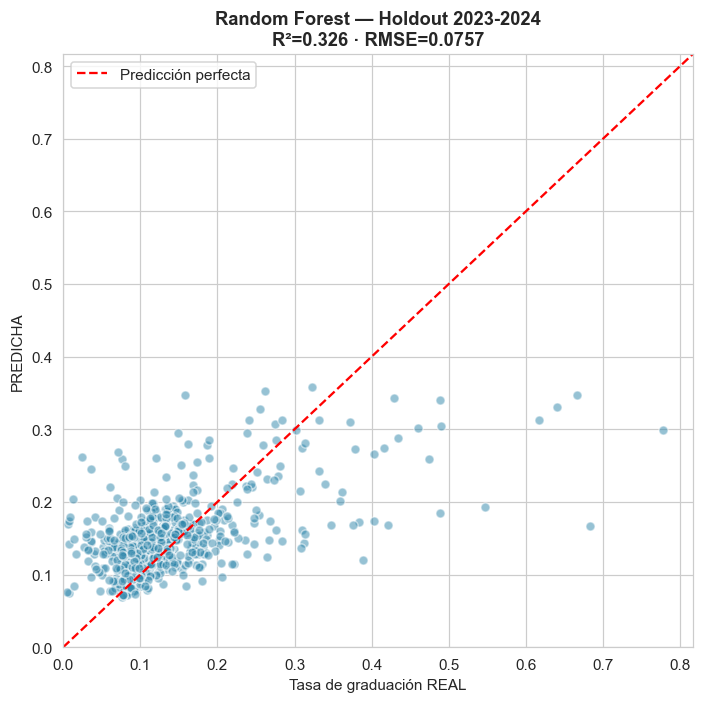

In [7]:
mejor = res.iloc[0]['Modelo']
pred = preds_test[mejor]
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, pred, alpha=0.5, color=COLORS[0], edgecolors='white', s=35)
lim = [0, max(y_test.max(), pred.max())*1.05]
ax.plot(lim, lim, 'r--', label='Predicción perfecta')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Tasa de graduación REAL'); ax.set_ylabel('PREDICHA')
ax.set_title(f'{mejor} — Holdout 2023-2024\n'
             f"R²={res.iloc[0]['R² holdout']:.3f} · RMSE={res.iloc[0]['RMSE holdout']:.4f}")
ax.legend(); plt.tight_layout(); plt.show()

### A.5 Importancia de variables (permutación sobre el holdout)

Medimos cuánto cae el R² al permutar aleatoriamente cada variable: cuanto más cae,
más importante es esa variable para el modelo.

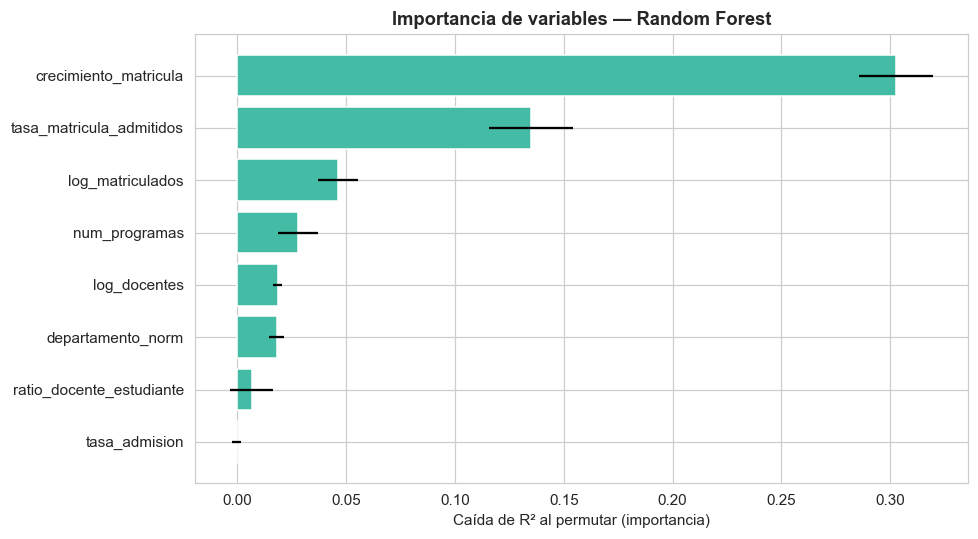

,feature,importancia,std
6,crecimiento_matricula,0.3028,0.0169
4,tasa_matricula_admitidos,0.1350,0.0192
0,log_matriculados,0.0462,0.0091
5,num_programas,0.0280,0.0093
1,log_docentes,0.0184,0.0021
7,departamento_norm,0.0181,0.0036
2,ratio_docente_estudiante,0.0065,0.0100
3,tasa_admision,-0.0005,0.0020


In [8]:
mejor_pipe = modelos[mejor]
perm = permutation_importance(mejor_pipe, X_test, y_test, n_repeats=15,
                              random_state=RANDOM_STATE, scoring='r2')
imp = (pd.DataFrame({'feature': ALL_FEATS, 'importancia': perm.importances_mean,
                     'std': perm.importances_std})
       .sort_values('importancia'))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp['feature'], imp['importancia'], xerr=imp['std'], color=COLORS[5])
ax.set_xlabel('Caída de R² al permutar (importancia)')
ax.set_title(f'Importancia de variables — {mejor}')
plt.tight_layout(); plt.show()
imp.sort_values('importancia', ascending=False).round(4)

**Lectura de la importancia:**
- **`crecimiento_matricula`** es la variable más predictiva: las IES en **expansión
  acelerada** muestran tasas de graduación más bajas (sus cohortes nuevas aún no se
  gradúan), y las que decrecen, más altas. Es una **dinámica de cohorte**, no causalidad.
- **`tasa_matricula_admitidos`** (conversión admitido→matriculado) es la 2.ª: refleja
  la solidez del embudo de matrícula.
- **`ratio_docente_estudiante`** aporta de forma moderada → más dotación docente se
  asocia a mayor graduación, pero **no** es el único factor (ver Parte B).

### A.6 Validación del modelo (overfitting, supuestos)

- **CV (5-fold) ≈ holdout** para Random Forest (~0.31 vs ~0.33): el desempeño es
  **estable** y la generalización a años no vistos (2023–24) se confirma.
- La brecha train–holdout existe (propia de RF) pero **CV y holdout coinciden**, que
  es la señal real de generalización.
- **R² ≈ 0.33 → poder predictivo moderado:** la tasa de graduación depende también de
  factores no presentes en los datos (calidad académica, becas, deserción, programas
  específicos). El modelo **es útil para priorizar y comparar**, no para predicción exacta.

---
# PARTE B · Modelo NO SUPERVISADO — Segmentación de IES

**Pregunta de negocio (Fase 1, Q2):** *¿Cómo se agrupan las IES colombianas según su
perfil operativo?* No hay etiqueta previa → **clustering**.

### B.1 Preparación — perfil estable por IES

- Una fila por **IES**, promediando los años recientes **2022–2024** (perfil estable,
  menos ruido anual).
- 4 variables que capturan dimensiones distintas del perfil operativo:
  **tamaño** (`log_matriculados`), **intensidad docente** (`ratio_docente_estudiante`),
  **eficiencia de salida** (`tasa_graduacion`) y **amplitud de oferta** (`num_programas`).
- **`StandardScaler` obligatorio** (KMeans usa distancias euclídeas).
- Winsorización al percentil 1–99 para acotar outliers extremos.

In [9]:
rec = df[(df['año'].between(2022, 2024)) & (df['matriculados'] > 0)].copy()
rec['log_matriculados'] = np.log1p(rec['matriculados'])
perfil = (rec.groupby('codigo_ies')
          .agg(nombre_ies=('nombre_ies','first'),
               departamento=('departamento_norm','first'),
               sector=('sector_norm','first'),
               log_matriculados=('log_matriculados','mean'),
               matriculados=('matriculados','mean'),
               docentes=('docentes','mean'),
               ratio_docente_estudiante=('ratio_docente_estudiante','mean'),
               tasa_graduacion=('tasa_graduacion','mean'),
               num_programas=('num_programas','mean')).reset_index())

CLUSTER_FEATS = ['log_matriculados', 'ratio_docente_estudiante',
                 'tasa_graduacion', 'num_programas']
perfil = perfil.dropna(subset=['log_matriculados','ratio_docente_estudiante','tasa_graduacion'])
for c in CLUSTER_FEATS:
    perfil[c] = perfil[c].fillna(perfil[c].median())
    lo, hi = perfil[c].quantile([0.01, 0.99]); perfil[c] = perfil[c].clip(lo, hi)

scaler = StandardScaler()
Xc = scaler.fit_transform(perfil[CLUSTER_FEATS])
print(f'IES con perfil completo (2022-2024): {len(perfil)}')

IES con perfil completo (2022-2024): 323


### B.2 Selección del número de clústeres (método del codo + Silhouette)

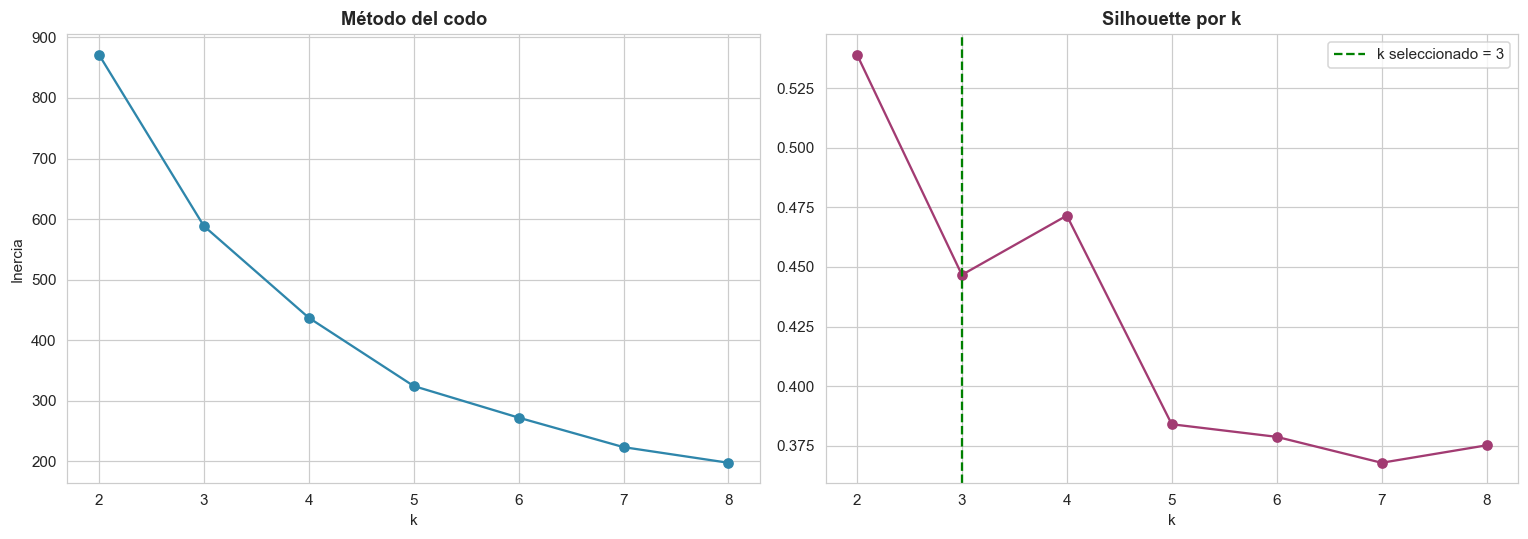

,k,inercia,silhouette
0,2,871.6,0.539
1,3,588.6,0.447
2,4,437.1,0.472
3,5,324.3,0.384
4,6,272.1,0.379
5,7,223.4,0.368
6,8,197.5,0.375


In [10]:
ks = range(2, 9); inercias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(Xc)
    inercias.append(km.inertia_); sils.append(silhouette_score(Xc, lab))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(ks), inercias, 'o-', color=COLORS[0])
axes[0].set_title('Método del codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(list(ks), sils, 'o-', color=COLORS[1])
axes[1].axvline(3, ls='--', color='green', label='k seleccionado = 3')
axes[1].set_title('Silhouette por k'); axes[1].set_xlabel('k'); axes[1].legend()
plt.tight_layout(); plt.show()
pd.DataFrame({'k': list(ks), 'inercia': np.round(inercias,1), 'silhouette': np.round(sils,3)})

**Decisión de `k`:** el silhouette es máximo en **k=2 (0.54)**, pero ese corte solo
aísla un puñado de micro-IES dejando un macro-grupo enorme y heterogéneo (poco
accionable). Elegimos **k=3** porque:
1. mantiene el silhouette en zona razonable (**0.45**),
2. coincide con el **codo** de la inercia, y
3. produce **3 arquetipos operativos** con valor directo para los stakeholders.

### B.3 Comparación de algoritmos (k=3) y perfilado

In [11]:
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
lab_km = km.fit_predict(Xc)
lab_agg = AgglomerativeClustering(n_clusters=3).fit_predict(Xc)
lab_db = DBSCAN(eps=1.2, min_samples=5).fit_predict(Xc)
n_db = len(set(lab_db)) - (1 if -1 in lab_db else 0)
print(f'KMeans (k=3)        silhouette = {silhouette_score(Xc, lab_km):.3f}')
print(f'Agglomerative (k=3) silhouette = {silhouette_score(Xc, lab_agg):.3f}')
print(f'DBSCAN              silhouette = '
      f'{silhouette_score(Xc[lab_db!=-1], lab_db[lab_db!=-1]):.3f} '
      f'({n_db} clústeres, {(lab_db==-1).sum()} IES de ruido)')
print('\n-> Seleccionado KMeans: DBSCAN logra mayor silhouette pero descarta IES '
      'como ruido y colapsa a 2 grupos; KMeans asigna TODAS las IES a 3 arquetipos.')

KMeans (k=3)        silhouette = 0.447
Agglomerative (k=3) silhouette = 0.411
DBSCAN              silhouette = 0.684 (2 clústeres, 15 IES de ruido)

-> Seleccionado KMeans: DBSCAN logra mayor silhouette pero descarta IES como ruido y colapsa a 2 grupos; KMeans asigna TODAS las IES a 3 arquetipos.


In [12]:
perfil['cluster'] = lab_km
resumen = (perfil.groupby('cluster')
           .agg(n_ies=('codigo_ies','count'),
                matriculados_med=('matriculados','median'),
                docentes_med=('docentes','median'),
                ratio_doc_est=('ratio_docente_estudiante','median'),
                tasa_graduacion=('tasa_graduacion','median'),
                num_programas=('num_programas','median')).reset_index())
orden = resumen.sort_values('matriculados_med')['cluster'].tolist()
nombres = {orden[0]:'Pequeñas especializadas', orden[-1]:'Mega-masivas'}
for cl in orden[1:-1]: nombres[cl] = 'Medianas tradicionales'
resumen['arquetipo'] = resumen['cluster'].map(nombres)
perfil['arquetipo'] = perfil['cluster'].map(nombres)
resumen[['arquetipo','n_ies','matriculados_med','docentes_med',
         'ratio_doc_est','tasa_graduacion','num_programas']].round(3)

,arquetipo,n_ies,matriculados_med,docentes_med,ratio_doc_est,tasa_graduacion,num_programas
0,Mega-masivas,68,31323.500,2488.333,0.077,0.117,133.0
1,Medianas tradicionales,226,4646.667,314.500,0.082,0.119,25.0
2,Pequeñas especializadas,29,127.000,43.333,0.450,0.311,5.0


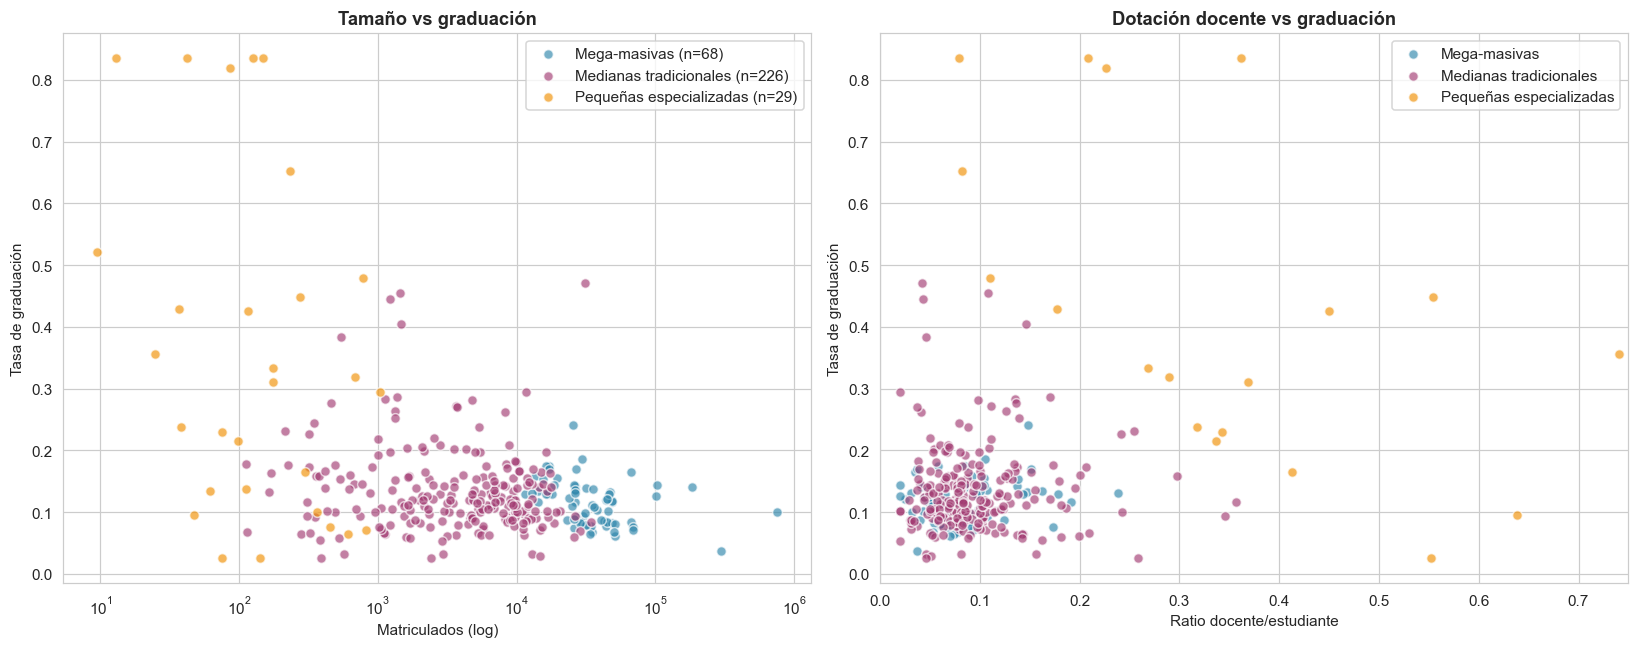

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for cl in sorted(perfil['cluster'].unique()):
    s = perfil[perfil['cluster'] == cl]
    axes[0].scatter(s['matriculados'], s['tasa_graduacion'], alpha=0.65, s=40,
                    color=COLORS[cl % len(COLORS)], edgecolors='white',
                    label=f"{nombres[cl]} (n={len(s)})")
    axes[1].scatter(s['ratio_docente_estudiante'], s['tasa_graduacion'], alpha=0.65,
                    s=40, color=COLORS[cl % len(COLORS)], edgecolors='white',
                    label=nombres[cl])
axes[0].set_xscale('log'); axes[0].set_xlabel('Matriculados (log)')
axes[0].set_ylabel('Tasa de graduación'); axes[0].set_title('Tamaño vs graduación'); axes[0].legend()
axes[1].set_xlabel('Ratio docente/estudiante'); axes[1].set_ylabel('Tasa de graduación')
axes[1].set_xlim(0, perfil['ratio_docente_estudiante'].quantile(0.97))
axes[1].set_title('Dotación docente vs graduación'); axes[1].legend()
plt.tight_layout(); plt.show()

### B.4 Interpretación de los clústeres

| Arquetipo | n IES | Matrícula (mediana) | Ratio docente/est. | Tasa graduación | Programas |
|---|---|---|---|---|---|
| 🟦 **Mega-masivas** | 68 | ~31.000 | 0,077 | 0,117 | 133 |
| 🟪 **Medianas tradicionales** | 226 | ~4.600 | 0,082 | 0,119 | 25 |
| 🟧 **Pequeñas especializadas** | 29 | ~130 | **0,45** | **0,31** | 5 |

**Hallazgo central:** las **Pequeñas especializadas** tienen ~**5× más docentes por
estudiante** y una **tasa de graduación ≈2,6× mayor** que las mega-masivas. La
dotación docente intensiva, en instituciones pequeñas y enfocadas, se asocia a mucha
mayor eficiencia de graduación.

---
# Insights para los stakeholders

1. **Para el Ministerio de Educación:** existe un grupo de ~29 IES *pequeñas
   especializadas* con tasas de graduación ~2,6× superiores al promedio, sostenidas
   por una dotación docente ~5× mayor. La política de fortalecimiento docente es
   palanca de eficiencia, **especialmente en instituciones medianas y masivas**.

2. **Para rectores de IES:** el modelo supervisado indica que la **conversión
   admitido→matriculado** y la **dinámica de crecimiento de matrícula** son señales
   tempranas más fuertes que el tamaño. Las IES en expansión acelerada deben
   anticipar una caída transitoria de su tasa de graduación (efecto cohorte).

3. **Para ICETEX / gobernaciones:** la segmentación permite **focalizar recursos** por
   arquetipo en lugar de tratar a todas las IES por igual (656 IES → 3 perfiles).

4. **Valor analítico:** se pasa de 8.805 registros crudos a **2 modelos accionables**:
   uno que *predice* la eficiencia de graduación y otro que *segmenta* el sistema.

# Limitaciones y supuestos

- **`sector`/`caracter`** disponibles en solo ~5% de los registros → excluidos como
  predictores. Con esa metadata, el modelo probablemente mejoraría.
- **R² ≈ 0,33:** poder predictivo **moderado**; la tasa de graduación depende de
  factores no medidos (deserción, calidad, becas, tipo de programa).
- **`tasa_graduacion` = graduados/matriculados** es una proxy anual; `matriculados`
  es un *stock* acumulado, no solo nuevos → interpretar como eficiencia relativa.
- El clustering usa el **promedio 2022–2024**; cambios estructurales recientes podrían
  no reflejarse aún.
- Supuesto: la relación features→graduación es **estable en el tiempo** (validado con
  holdout 2023–2024, pero podría cambiar ante reformas).

# Artefactos generados
- `models/modelo_regresion_tasa_graduacion.joblib` — modelo supervisado entrenado.
- `models/modelo_clustering_ies.joblib` — scaler + KMeans del clustering.
- `data/dataset/ies_clusters.csv` — cada IES con su arquetipo (para el dashboard).
- `reports/modelado_visualizaciones/` — 6 gráficos (13–18).
- `reports/modelado_metricas.json` — todas las métricas.

> Pipeline reproducible completo en `scripts/run_modelado.py`.